In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)

In [2]:
class UNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.enc1 = nn.Conv2d(1, 16, 3, padding=1)
        self.enc2 = nn.Conv2d(16, 32, 3, padding=1)

        self.pool = nn.MaxPool2d(2)

        self.up = nn.ConvTranspose2d(
            32, 16, 2, stride=2
        )

        self.out = nn.Conv2d(
            32, 1, 1
        )

    def forward(self, x):

        e1 = torch.relu(self.enc1(x))
        e2 = torch.relu(self.enc2(self.pool(e1)))

        d = self.up(e2)

        d = torch.cat([d, e1], dim=1)

        return self.out(d)

In [3]:
def dice_loss(pred, target, eps=1e-6):

    pred = torch.sigmoid(pred)

    intersection = (pred * target).sum()

    dice = (
        2 * intersection + eps
    ) / (
        pred.sum() + target.sum() + eps
    )

    return 1 - dice

In [4]:
def combined_loss(pred, target):

    bce = nn.functional.binary_cross_entropy_with_logits(
        pred, target
    )

    dice = dice_loss(pred, target)

    return bce + dice

In [5]:
X = torch.randn(8, 1, 64, 64)

Y = (torch.rand(8, 1, 64, 64) > 0.5).float()

model = UNet()

print("Input :", X.shape)
print("Target:", Y.shape)

Input : torch.Size([8, 1, 64, 64])
Target: torch.Size([8, 1, 64, 64])


In [6]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

losses = []

for epoch in range(20):

    optimizer.zero_grad()

    pred = model(X)

    loss = combined_loss(pred, Y)

    loss.backward()

    optimizer.step()

    losses.append(loss.item())

    if epoch % 5 == 0:
        print(
            f"Epoch {epoch}, Loss: {loss.item():.4f}"
        )

Epoch 0, Loss: 1.2375
Epoch 5, Loss: 1.2066
Epoch 10, Loss: 1.1782
Epoch 15, Loss: 1.1705


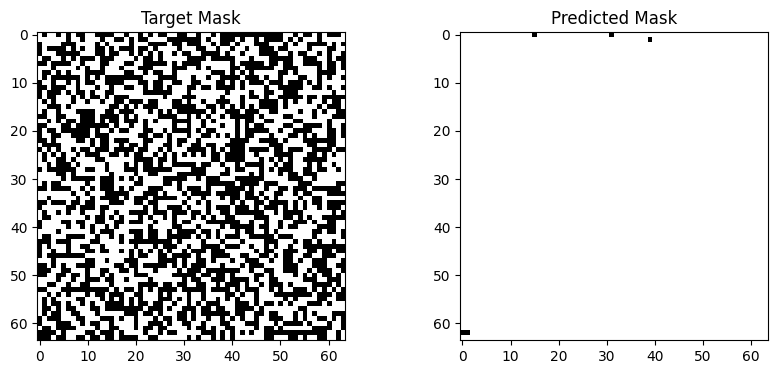

In [7]:
pred = torch.sigmoid(
    model(X)
)[0, 0].detach()

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(Y[0, 0], cmap="gray")
plt.title("Target Mask")

plt.subplot(1, 2, 2)
plt.imshow(pred > 0.5, cmap="gray")
plt.title("Predicted Mask")

plt.show()

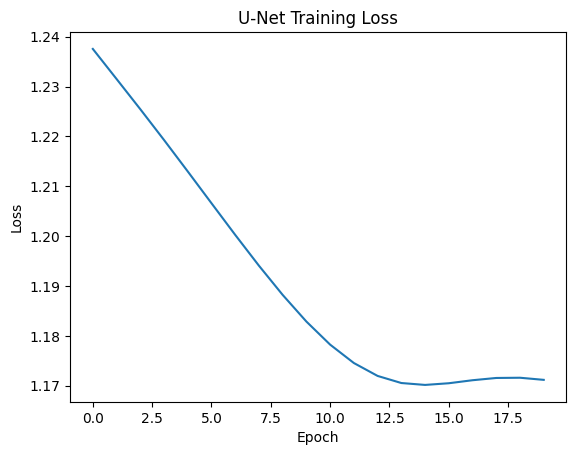

In [8]:
plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("U-Net Training Loss")

plt.show()

In [9]:
print("U-Net semantic segmentation completed.")
print("Soft Dice Loss + Binary Cross-Entropy were used.")

U-Net semantic segmentation completed.
Soft Dice Loss + Binary Cross-Entropy were used.
